# Yield prediction model comparison: OLS, Ridge, Random Forest, Ridge+PCA

This notebook trains and compares four models to predict **Mean_Yield**:

1. **OLS** (ordinary least squares)
2. **Ridge** (L2-regularized linear regression)
3. **Random Forest** (non-linear ensemble)
4. **Ridge + PCA** (principal components on numeric climate features + ridge)

The goal is to make the comparison **easy to visualize** with:
- a compact metrics table
- bar charts (R², RMSE)
- predicted vs actual plots for each model

> Notes
> - This notebook assumes your data file is named `yields_weather_by_crop.csv` and exists in a `prepared/` folder (or nearby).
> - It automatically detects categorical columns (like `Municipality`, `Crop`) and one-hot encodes them.
> - It applies scaling only where needed (linear models).


In [123]:
# === Imports ===
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import train_test_split, GroupKFold, LeaveOneGroupOut
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA

from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

RANDOM_STATE = 42

SPLIT_METHOD = "group_kfold_year"   # "random", "last_years", "random_years", "group_kfold_year", "leave_one_year_out"

In [124]:
# === Load data ===
data_path = "./prepared/yields_weather_by_crop.csv"

df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()


Shape: (4864, 76)


,Year,Municipality,Crop,Mean_Yield,05_Q1_CDD,05_Q2_CDD,06_Q1_CDD,06_Q2_CDD,07_Q1_CDD,07_Q2_CDD,...,06_Q1_Ptol,06_Q2_Ptol,07_Q1_Ptol,07_Q2_Ptol,08_Q1_Ptol,08_Q2_Ptol,09_Q1_Ptol,09_Q2_Ptol,10_Q1_Ptol,10_Q2_Ptol
0,1996,ALEXANDER,ARGENTINE CANOLA,0.728428,0.0,1.406025,32.701730,41.166500,31.423716,15.575997,...,0.016586,0.029817,0.080075,0.068031,0.044390,0.045396,0.053233,0.024934,0.015926,0.030042
1,1996,ALEXANDER,OATS,1.215000,0.0,1.406025,32.701730,41.166500,31.423716,15.575997,...,0.016586,0.029817,0.080075,0.068031,0.044390,0.045396,0.053233,0.024934,0.015926,0.030042
2,1996,ALONSA,ALFALFA/GRASS MIX.,1.609253,0.0,2.014729,37.197368,35.920028,39.128350,18.739317,...,0.016910,0.034612,0.058935,0.080042,0.030213,0.010850,0.033199,0.015887,0.017048,0.052276
3,1996,ARGYLE,ALFALFA,2.080575,0.0,0.152813,24.440870,34.404783,27.131971,17.745561,...,0.030000,0.060000,0.030000,0.070000,0.030000,0.030000,0.020000,0.020000,0.000000,0.020000
4,1996,ARGYLE,ALFALFA/GRASS MIX.,1.658000,0.0,0.152813,24.440870,34.404783,27.131971,17.745561,...,0.030000,0.060000,0.030000,0.070000,0.030000,0.030000,0.020000,0.020000,0.000000,0.020000


In [125]:
# === Split features/target ===
TARGET = "Mean_Yield"

y = df[TARGET]
X = df.drop(columns=[TARGET])

# Identify categorical vs numeric
cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype).startswith("category")]
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"Numeric columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")
print("Categorical columns:", cat_cols)


Numeric columns: 73
Categorical columns: 2
Categorical columns: ['Municipality', 'Crop']


In [126]:
# === Train/test split ===

def split_dataset(
    X,
    y,
    method="random",
    test_size=0.2,
    n_test_years=3,
    random_state=42,
    n_splits=3,
):
    """
    Split dataset using different strategies.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix. Must contain 'Year' column for year-based methods.
    y : pd.Series or pd.DataFrame
        Target variable.
    method : str
        - 'random'             : random observation split
        - 'last_years'         : last n_test_years used for test
        - 'random_years'       : randomly choose n_test_years for test
        - 'group_kfold_year'   : cross-validation grouped by Year
        - 'leave_one_year_out' : cross-validation leaving one year out each fold
    test_size : float
        Test proportion for random split.
    n_test_years : int
        Number of test years for year-based holdout splits.
    random_state : int
        Random seed.
    n_splits : int
        Number of folds for GroupKFold.

    Returns
    -------
    If method in {'random', 'last_years', 'random_years'}:
        X_train, X_test, y_train, y_test

    If method in {'group_kfold_year', 'leave_one_year_out'}:
        splits : list of tuples
            Each tuple is (X_train, X_test, y_train, y_test, test_years)
    """

    if method == "random":
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )
        print("Train size:", X_train.shape, "Test size:", X_test.shape)
        return X_train, X_test, y_train, y_test

    elif method == "last_years":
        years = sorted(X["Year"].unique())
        test_years = years[-n_test_years:]

        print("Test years:", test_years)

        train_mask = ~X["Year"].isin(test_years)
        test_mask = X["Year"].isin(test_years)

        X_train = X.loc[train_mask]
        X_test = X.loc[test_mask]
        y_train = y.loc[train_mask]
        y_test = y.loc[test_mask]

        print("Train size:", X_train.shape, "Test size:", X_test.shape)
        return X_train, X_test, y_train, y_test

    elif method == "random_years":
        rng = np.random.default_rng(random_state)

        years = X["Year"].unique()
        test_years = rng.choice(years, size=n_test_years, replace=False)

        print("Test years:", sorted(test_years))

        train_mask = ~X["Year"].isin(test_years)
        test_mask = X["Year"].isin(test_years)

        X_train = X.loc[train_mask]
        X_test = X.loc[test_mask]
        y_train = y.loc[train_mask]
        y_test = y.loc[test_mask]

        print("Train size:", X_train.shape, "Test size:", X_test.shape)
        return X_train, X_test, y_train, y_test

    elif method == "group_kfold_year":
        groups = X["Year"]
        unique_years = np.sort(groups.unique())

        if n_splits > len(unique_years):
            raise ValueError(
                f"n_splits={n_splits} is larger than number of unique years={len(unique_years)}"
            )

        gkf = GroupKFold(n_splits=n_splits)
        splits = []

        for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            test_years = sorted(X_test["Year"].unique())
            print(
                f"Fold {fold}: test years = {test_years} | "
                f"Train size: {X_train.shape} | Test size: {X_test.shape}"
            )

            splits.append((X_train, X_test, y_train, y_test, test_years))

        return splits

    elif method == "leave_one_year_out":
        groups = X["Year"]
        logo = LeaveOneGroupOut()
        splits = []

        for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups=groups), start=1):
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            test_years = sorted(X_test["Year"].unique())
            print(
                f"Fold {fold}: test year = {test_years} | "
                f"Train size: {X_train.shape} | Test size: {X_test.shape}"
            )

            splits.append((X_train, X_test, y_train, y_test, test_years))

        return splits

    else:
        raise ValueError(
            "method must be one of: "
            "'random', 'last_years', 'random_years', "
            "'group_kfold_year', 'leave_one_year_out'"
        )

In [127]:
# === Choose split strategy ===

split_output = split_dataset(
    X,
    y,
    method=SPLIT_METHOD,
    test_size=0.2,
    n_test_years=4,
    random_state=RANDOM_STATE,
    n_splits=4,
)

Fold 1: test years = [np.int64(1999), np.int64(2003), np.int64(2007), np.int64(2011)] | Train size: (3648, 75) | Test size: (1216, 75)
Fold 2: test years = [np.int64(1998), np.int64(2002), np.int64(2006), np.int64(2010)] | Train size: (3648, 75) | Test size: (1216, 75)
Fold 3: test years = [np.int64(1997), np.int64(2001), np.int64(2005), np.int64(2009)] | Train size: (3648, 75) | Test size: (1216, 75)
Fold 4: test years = [np.int64(1996), np.int64(2000), np.int64(2004), np.int64(2008)] | Train size: (3648, 75) | Test size: (1216, 75)


## Preprocessing

We use a **ColumnTransformer**:

- **Numeric**: median imputation + (optionally) scaling
- **Categorical**: most-frequent imputation + one-hot encoding

Scaling is applied for linear models (OLS/Ridge/Ridge+PCA). Random Forest does not need scaling.


In [128]:
# === Preprocessing blocks ===

numeric_imputer = SimpleImputer(strategy="median")

categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocess_for_linear = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("impute", numeric_imputer), ("scale", StandardScaler())]), num_cols),
        ("cat", Pipeline([("onehot", categorical_encoder)]), cat_cols),
    ],
    remainder="drop",
)

preprocess_for_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("impute", numeric_imputer)]), num_cols),
        ("cat", Pipeline([("onehot", categorical_encoder)]), cat_cols),
    ],
    remainder="drop",
)


## Models

- **OLS**: `LinearRegression()`
- **Ridge**: `Ridge(alpha=...)`
- **Random Forest**: `RandomForestRegressor(...)`
- **Ridge + PCA**: PCA is applied **only to numeric features** (after scaling), then concatenated with one-hot categorical features, then Ridge.

We keep the hyperparameters simple and reasonable as a baseline.


In [129]:
# === Define model pipelines ===

ols = Pipeline([
    ("prep", preprocess_for_linear),
    ("model", LinearRegression()),
])

ridge = Pipeline([
    ("prep", preprocess_for_linear),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

rf = Pipeline([
    ("prep", preprocess_for_rf),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=2,
    )),
])

# Ridge + PCA: build a transformer that applies PCA only to numeric block
numeric_pca = Pipeline([
    ("impute", numeric_imputer),
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),  # keep 95% variance
])

prep_ridge_pca = ColumnTransformer(
    transformers=[
        ("num_pca", numeric_pca, num_cols),
        ("cat", Pipeline([ ("onehot", categorical_encoder)]), cat_cols),
    ],
    remainder="drop",
)

ridge_pca = Pipeline([
    ("prep", prep_ridge_pca),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

models = {
    "OLS": ols,
    "Ridge": ridge,
    "Random Forest": rf,
    "Ridge + PCA": ridge_pca,
}

list(models.keys())


['OLS', 'Ridge', 'Random Forest', 'Ridge + PCA']

In [130]:
# === Fit + evaluate ===

def evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mse = mean_squared_error(y_test, pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_test, pred)

    return {
        "mse": float(mse),
        "rmse": rmse,
        "r2": float(r2),
        "pred": pred,
        "y_true": np.asarray(y_test),
        "model": model,
    }


def evaluate_models(models, split_output, split_method):
    """
    Evaluate models for either:
    - a single holdout split
    - or a list of CV folds
    """
    results = {}

    # --- Case 1: single split ---
    if split_method in {"random", "last_years", "random_years"}:
        X_train, X_test, y_train, y_test = split_output

        for name, model in models.items():
            results[name] = evaluate(model, X_train, y_train, X_test, y_test)

        metrics = (
            pd.DataFrame({
                k: {
                    "R2": v["r2"],
                    "RMSE": v["rmse"],
                    "MSE": v["mse"]
                }
                for k, v in results.items()
            })
            .T
            .sort_values("R2", ascending=False)
        )

        return results, metrics

    # --- Case 2: cross-validation ---
    elif split_method in {"group_kfold_year", "leave_one_year_out"}:
        cv_results = {}

        for name, model in models.items():
            fold_results = []

            for fold_id, (X_train, X_test, y_train, y_test, test_years) in enumerate(split_output, start=1):
                fold_eval = evaluate(model, X_train, y_train, X_test, y_test)
                fold_eval["fold"] = fold_id
                fold_eval["test_years"] = test_years
                fold_results.append(fold_eval)

            cv_results[name] = fold_results

        # aggregate metrics
        rows = []
        for name, fold_results in cv_results.items():
            r2s = [fr["r2"] for fr in fold_results]
            rmses = [fr["rmse"] for fr in fold_results]
            mses = [fr["mse"] for fr in fold_results]

            rows.append({
                "Model": name,
                "R2_mean": np.mean(r2s),
                "R2_std": np.std(r2s, ddof=1) if len(r2s) > 1 else 0.0,
                "RMSE_mean": np.mean(rmses),
                "RMSE_std": np.std(rmses, ddof=1) if len(rmses) > 1 else 0.0,
                "MSE_mean": np.mean(mses),
                "MSE_std": np.std(mses, ddof=1) if len(mses) > 1 else 0.0,
            })

        metrics = (
            pd.DataFrame(rows)
            .set_index("Model")
            .sort_values("R2_mean", ascending=False)
        )

        return cv_results, metrics

    else:
        raise ValueError("Unknown split_method")


In [131]:
results, metrics = evaluate_models(models, split_output, SPLIT_METHOD)
metrics

,R2_mean,R2_std,RMSE_mean,RMSE_std,MSE_mean,MSE_std
Model,,,,,,
Ridge + PCA,0.872850,0.059930,0.512105,0.076612,0.266654,0.083770
Random Forest,0.853530,0.056912,0.553267,0.095507,0.312946,0.102153
Ridge,0.727784,0.160056,0.742105,0.219894,0.586985,0.356778
OLS,0.703479,0.198041,0.764873,0.263980,0.637295,0.440683


## Easy-to-visualize comparison

1) **Metrics table** (above) sorted by R²

2) **Bar charts** for R² and RMSE

3) **Predicted vs actual** plots (one figure per model)


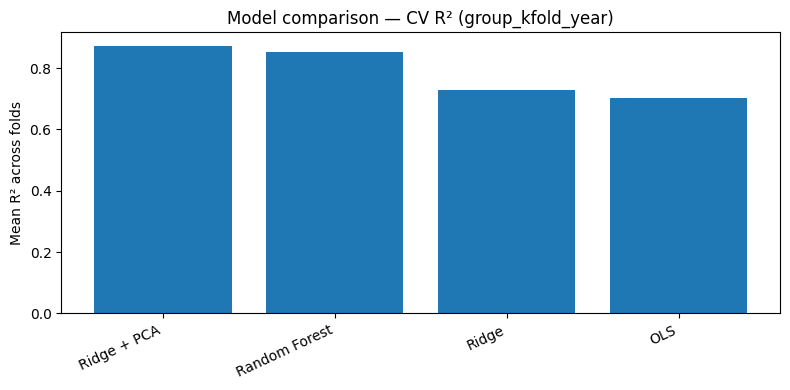

In [132]:
# === Bar chart: R² ===
plt.figure(figsize=(8, 4))

if SPLIT_METHOD in {"group_kfold_year", "leave_one_year_out"}:
    plt.bar(metrics.index, metrics["R2_mean"])
    plt.ylabel("Mean R² across folds")
    plt.title(f"Model comparison — CV R² ({SPLIT_METHOD})")
else:
    plt.bar(metrics.index, metrics["R2"])
    plt.ylabel("R²")
    plt.title("Model comparison — R² (higher is better)")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


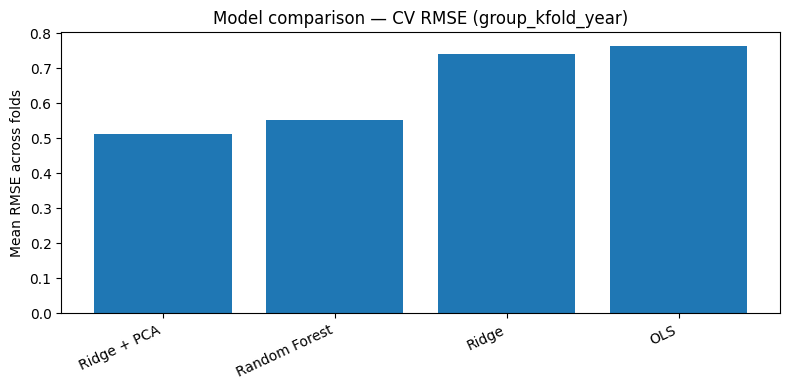

In [133]:
# === Bar chart: RMSE ===
plt.figure(figsize=(8, 4))

if SPLIT_METHOD in {"group_kfold_year", "leave_one_year_out"}:
    plt.bar(metrics.index, metrics["RMSE_mean"])
    plt.ylabel("Mean RMSE across folds")
    plt.title(f"Model comparison — CV RMSE ({SPLIT_METHOD})")
else:
    plt.bar(metrics.index, metrics["RMSE"])
    plt.ylabel("RMSE")
    plt.title("Model comparison — RMSE (lower is better)")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

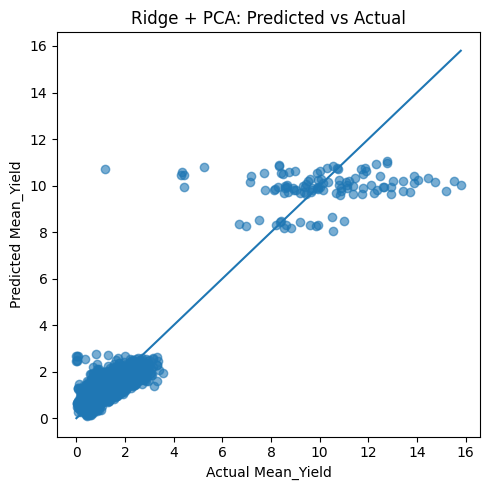

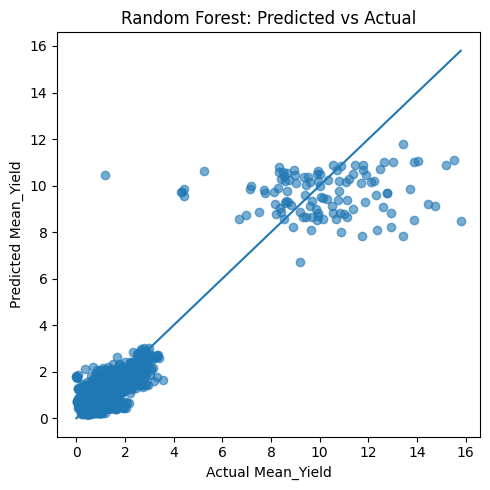

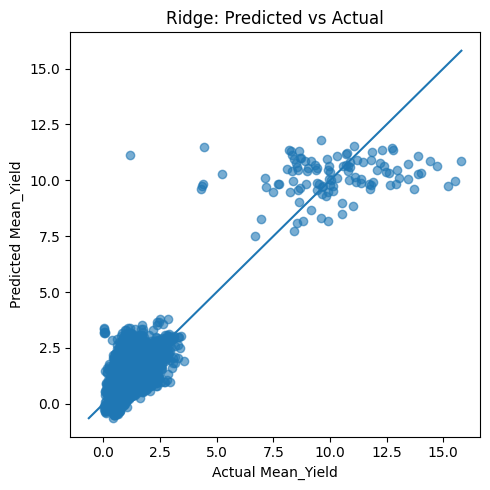

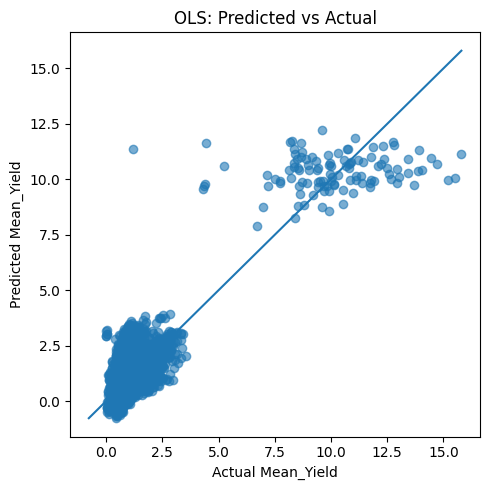

In [134]:
# === Predicted vs Actual ===

for name in metrics.index:
    if SPLIT_METHOD in {"group_kfold_year", "leave_one_year_out"}:
        y_true = np.concatenate([fold["y_true"] for fold in results[name]])
        y_pred = np.concatenate([fold["pred"] for fold in results[name]])
    else:
        y_true = results[name]["y_true"]
        y_pred = results[name]["pred"]

    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.6)

    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    plt.plot([lo, hi], [lo, hi])

    plt.xlabel("Actual Mean_Yield")
    plt.ylabel("Predicted Mean_Yield")
    plt.title(f"{name}: Predicted vs Actual")
    plt.tight_layout()
    plt.show()

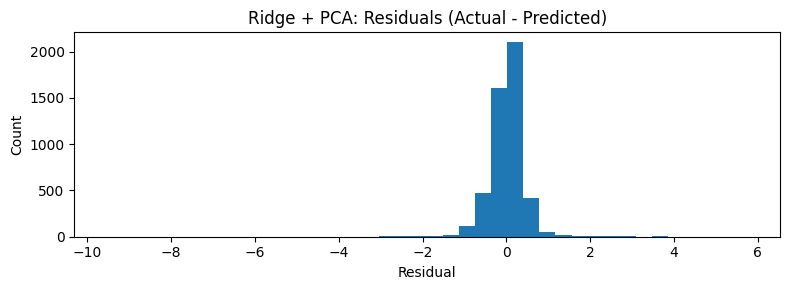

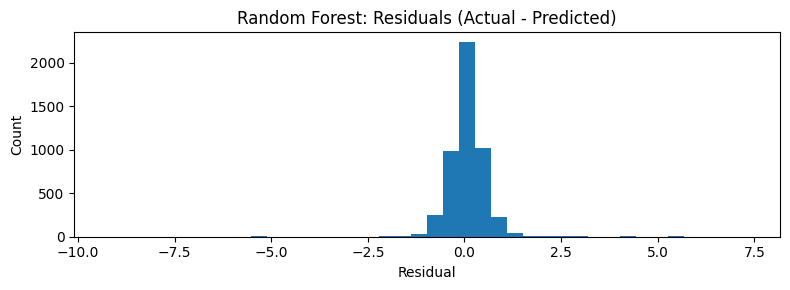

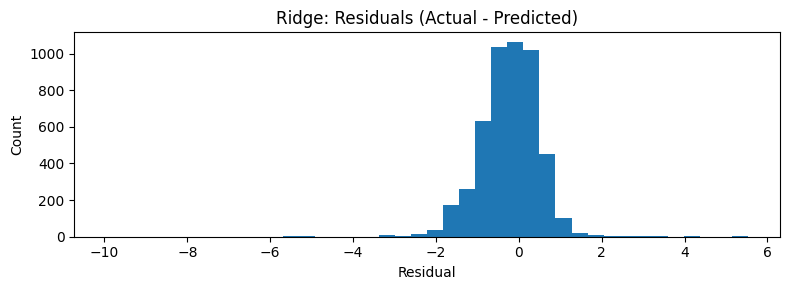

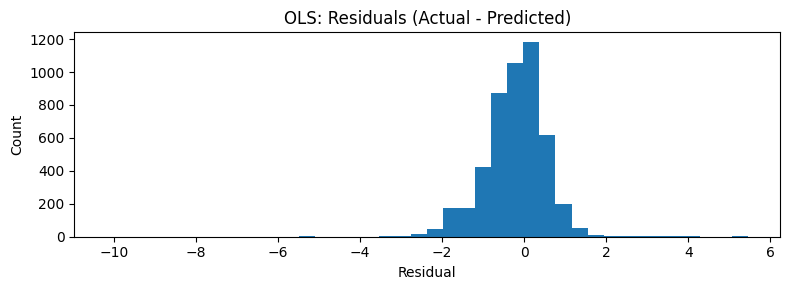

In [135]:
# === Residual distribution per model ===

for name in metrics.index:
    if SPLIT_METHOD in {"group_kfold_year", "leave_one_year_out"}:
        y_true = np.concatenate([fold["y_true"] for fold in results[name]])
        y_pred = np.concatenate([fold["pred"] for fold in results[name]])
    else:
        y_true = results[name]["y_true"]
        y_pred = results[name]["pred"]

    residuals = y_true - y_pred

    plt.figure(figsize=(8, 3))
    plt.hist(residuals, bins=40)
    plt.title(f"{name}: Residuals (Actual - Predicted)")
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


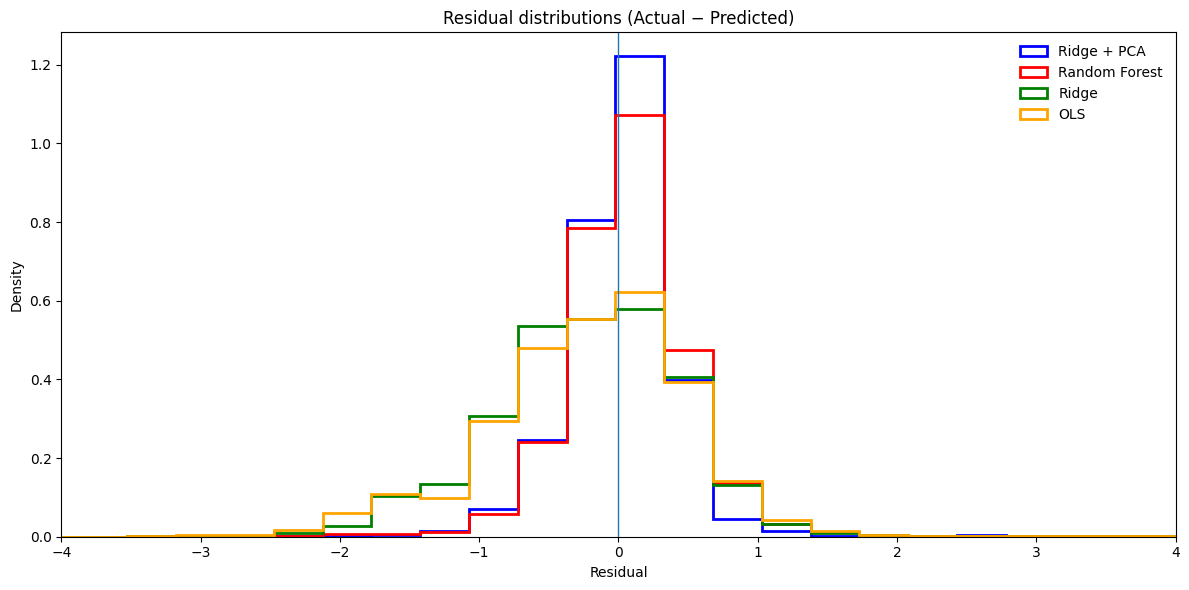

In [136]:
# === Combined residual distributions ===

residuals_by_model = {}

for name in metrics.index:
    if SPLIT_METHOD in {"group_kfold_year", "leave_one_year_out"}:
        y_true = np.concatenate([fold["y_true"] for fold in results[name]])
        y_pred = np.concatenate([fold["pred"] for fold in results[name]])
    else:
        y_true = results[name]["y_true"]
        y_pred = results[name]["pred"]

    residuals_by_model[name] = y_true - y_pred

all_res = np.concatenate(list(residuals_by_model.values()))
bins = np.histogram_bin_edges(all_res, bins=50)

colors = ["blue", "red", "green", "orange"]

plt.figure(figsize=(12, 6))

for (name, res), color in zip(residuals_by_model.items(), colors):
    plt.hist(
        res,
        bins=bins,
        histtype="step",
        linewidth=2,
        density=True,
        label=name,
        color=color
    )

plt.axvline(0, linewidth=1)
plt.xlim(-4, 4)
plt.title("Residual distributions (Actual − Predicted)")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
